# This notebook demonstrates how to fetch, subset, and visualize GFS 2‑m air temperature data for the Northeast U.S. region. The workflow includes downloading GRIB2 data, extracting the relevant area, and plotting temperature maps and statistics.

In [20]:
import os
import requests
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature


url = "https://nomads.ncep.noaa.gov/cgi-bin/filter_gfs_1p00.pl?dir=%2Fgfs.20251103%2F18%2Fatmos&file=gfs.t18z.pgrb2.1p00.f006&var_TMP=on&lev_2_m_above_ground=on"
local_fname = "gfs.t18z.pgrb2.1p00.f006.tmp2m.grib2"
output_plot = "tmp2m_northeast.png"


lat_min, lat_max = 38, 46
lon_min, lon_max = -80, -66

## Instructions

1. **Download** the GRIB2 file using the provided cell (skip if already present).
2. **Open** the file with xarray and cfgrib.
3. **Subset** the data to the Northeast U.S. using latitude and longitude bounds.
4. **Plot** and inspect the results.

In [21]:
def download_file(url, fname):
    if os.path.exists(fname):
        print(f"File already exists: {fname}")
        return
    print(f"Downloading {url} → {fname}")
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(fname, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete.")

def open_and_subset(fname, lat_min, lat_max, lon_min, lon_max):
    ds = xr.open_dataset(fname, engine='cfgrib')
    # convert longitudes if necessary
    if 'longitude' in ds.coords:
        try:
            if float(ds.longitude.max().values) > 180:
                ds = ds.assign_coords(longitude=((ds.longitude + 180) % 360) - 180).sortby('longitude')
        except Exception:
            pass
    ds_sub = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))
    return ds_sub

def quick_plot_tmp2m(ds, out=None):
    tmp = ds['t2m'] if 't2m' in ds else ds[list(ds.data_vars)[0]]
    tmp_c = tmp - 273.15
    lons = ds['longitude']
    lats = ds['latitude']
    plt.figure(figsize=(8,6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines()
    cs = ax.contourf(lons, lats, tmp_c, cmap='coolwarm', transform=ccrs.PlateCarree())
    plt.colorbar(cs, label='2 m temperature (°C)')
    if out:
        plt.savefig(out, dpi=150)
    plt.show()

## Expanded Workflow

The cell below runs the entire process: download, open, subset, and plot the temperature map for the Northeast U.S. Use this to validate the workflow end-to-end.

Download complete.
Subset variables: ['t2m']


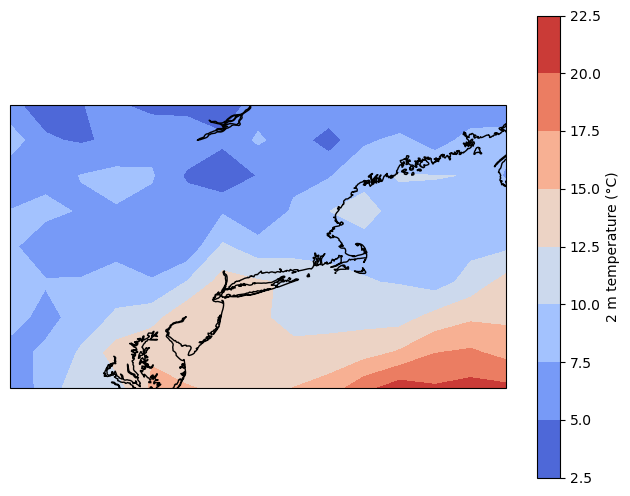

Plot saved to tmp2m_northeast.png


In [22]:
try:
    download_file(url, local_fname)
    ds_sub = open_and_subset(local_fname, lat_min, lat_max, lon_min, lon_max)
    print('Subset variables:', list(ds_sub.data_vars))
    quick_plot_tmp2m(ds_sub, out=output_plot)
    print(f'Plot saved to {output_plot}')
except Exception as e:
    print('Error in end-to-end run:', e)

## Quick Analysis & Statistics

Calculate basic statistics (mean, min, max) for the 2‑m temperature over the subset region. Visualize the distribution with a histogram to check for extremes and data quality.

Mean 2-m temperature: 9.59 °C
Min 2-m temperature: 2.86 °C
Max 2-m temperature: 21.36 °C


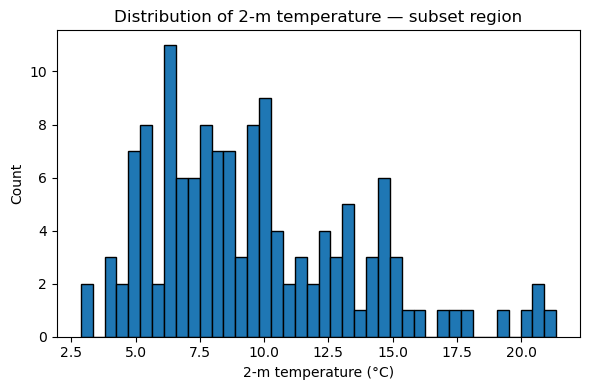

In [23]:
try:
    tmp_var = 't2m' if 't2m' in ds_sub else list(ds_sub.data_vars)[0]
    tmp = ds_sub[tmp_var]  # Kelvin
    tmp_c = tmp - 273.15  # °C

    mean_c = float(tmp_c.mean().values)
    min_c = float(tmp_c.min().values)
    max_c = float(tmp_c.max().values)
    print(f'Mean 2-m temperature: {mean_c:.2f} °C')
    print(f'Min 2-m temperature: {min_c:.2f} °C')
    print(f'Max 2-m temperature: {max_c:.2f} °C')

    
    plt.figure(figsize=(6,4))
    plt.hist(tmp_c.values.flatten(), bins=40, color='C0', edgecolor='k')
    plt.xlabel('2‑m temperature (°C)')
    plt.ylabel('Count')
    plt.title('Distribution of 2‑m temperature — subset region')
    plt.tight_layout()
    plt.show()
except NameError:
    print('ds_sub not defined. Run the download/open/subset cells first.')
except Exception as e:
    print('Error computing stats:', e)

## Final Map: 2‑m Temperature over the Northeast U.S.

Generate a high-quality contour map of 2‑m temperature for the region, including coastlines, borders, and state boundaries. The plot is saved as an image file.

Saved high-quality map to tmp2m_northeast_contour.png


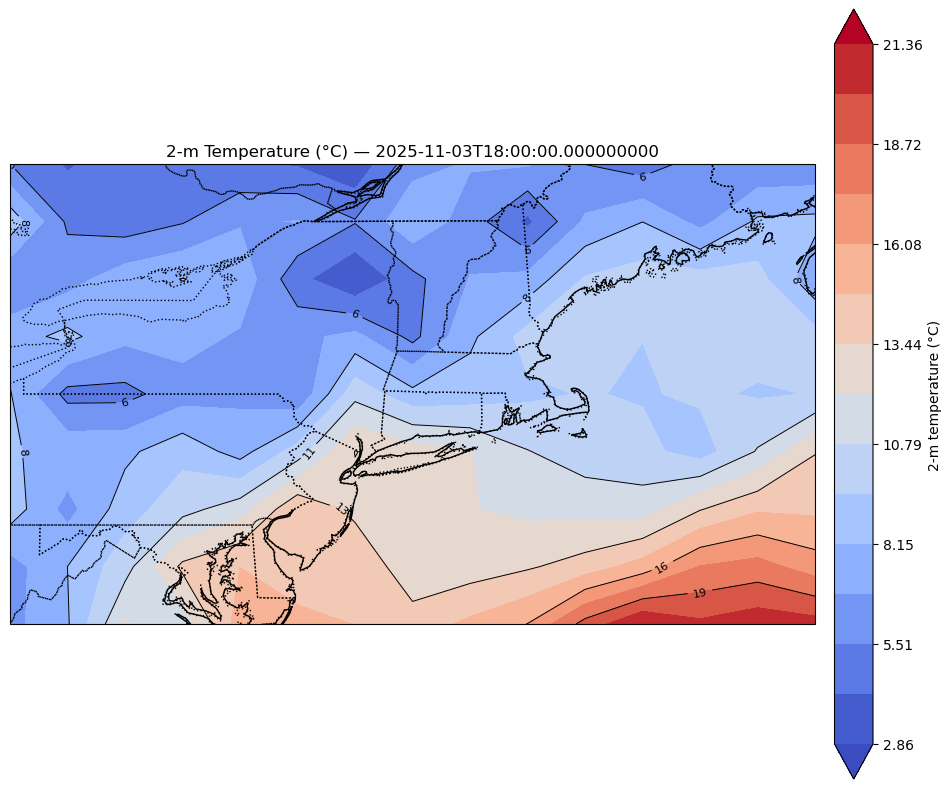

In [24]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    tmp_plot = tmp_c.squeeze()  
    lons = ds_sub['longitude']
    lats = ds_sub['latitude']

    fig, ax = plt.subplots(figsize=(10,8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='50m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    try:
        ax.add_feature(cfeature.STATES, linestyle=':')
    except Exception:
        pass

    vmin = float(tmp_plot.min().values); vmax = float(tmp_plot.max().values)
    levels = np.linspace(vmin, vmax, 15)

    cf = ax.contourf(lons, lats, tmp_plot, levels=levels, cmap='coolwarm', extend='both', transform=ccrs.PlateCarree())
    cs = ax.contour(lons, lats, tmp_plot, levels=levels[::2], colors='k', linewidths=0.7, transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt='%.0f', inline=1, fontsize=8)
    cbar = fig.colorbar(cf, ax=ax, orientation='vertical', pad=0.02, label='2‑m temperature (°C)')

    title_time = str(ds_sub.time.values) if 'time' in ds_sub.coords else ''
    ax.set_title(f'2‑m Temperature (°C) — {title_time}')
    outname = 'tmp2m_northeast_contour.png'
    plt.tight_layout()
    plt.savefig(outname, dpi=150)
    print(f'Saved high-quality map to {outname}')
    plt.show()
except NameError:
    print('ds_sub or tmp_c not defined. Run earlier cells first.')
except Exception as e:
    print('Error creating map:', e)